In [165]:
import os, sys

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)
# import default dict
from collections import defaultdict
# Imports
from stn_gpe import *
import numpy as np
from matplotlib import pyplot as plt
import scipy
from numpy.fft import fft, ifft
import math
from scipy.signal import spectrogram
from matplotlib.lines import Line2D
from tqdm.autonotebook import tqdm
from matplotlib.colors import LinearSegmentedColormap
# rc styling (Times New Roman + nicer defaults)
# ...existing code...
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "font.weight": "bold",         # global bold
    "axes.titlesize": 12,
    "axes.titleweight": "bold",    # bold axis titles
    "axes.labelsize": 11,
    "axes.labelweight": "bold",    # bold axis labels
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
    "axes.grid": False
})
import pickle
import torch
# ...existing code...

Project root added to sys.path: d:\charitha\projects\STN-GPe_spiking\light_house_DBS_decision_making


In [166]:
# reading pkl file path

folder_path = os.path.join(project_root, 'results', 'stn_gpe_system', 'data', 'std_DBS', 'raw_data', 'STD_DBS_PI_25')
file_path = os.path.join(folder_path, 'spikes.pkl')

In [167]:
with open(file_path, 'rb') as f:
        SPIKES_DATA = pickle.load(f)

lat_strength_arr = list(SPIKES_DATA.keys())

In [168]:
SPIKE_RATE_DATA = defaultdict(dict)

In [169]:
for i in tqdm(range(len(lat_strength_arr))):

        stn_lat = lat_strength_arr[i]
        Analysis_data = Analysis(SPIKES_DATA[stn_lat])

        # ******************* mean rate *********************************
        rate_data = Analysis_data.spike_rate(binsize = 100)
        STN_4 = torch.tensor(np.array([rate_data['1'], rate_data['2'], rate_data['3'], rate_data['4']]))
        STN_4_processed = torch.mean(STN_4.reshape(4,-1,100), dim = 2)
        STN_4_std = torch.std(STN_4, dim = 0)
        STN_4_std_processed = torch.std(STN_4_processed, dim = 0)
        SPIKE_RATE_DATA[stn_lat] = STN_4_processed
        
        print(f'lat: {stn_lat}; STD: {STN_4_std.mean()}; Processed STD: {STN_4_std_processed.mean()}')


  0%|          | 0/10 [00:00<?, ?it/s]

lat: 0.0275; STD: 0.04888354474641883; Processed STD: 0.03524183697119545
lat: 0.03; STD: 0.050127601620676; Processed STD: 0.03531446123387709
lat: 0.0325; STD: 0.04842521782280557; Processed STD: 0.03619421818062294
lat: 0.035; STD: 0.05153245560673989; Processed STD: 0.03837769871638044
lat: 0.037500000000000006; STD: 0.04807045694839633; Processed STD: 0.03510316298643778
lat: 0.04; STD: 0.04548608103108221; Processed STD: 0.032459992630366676
lat: 0.0425; STD: 0.0522441406127071; Processed STD: 0.034821838426300135
lat: 0.045; STD: 0.04749612038950929; Processed STD: 0.03236747608846376
lat: 0.0475; STD: 0.04754622368748621; Processed STD: 0.034482699451218755
lat: 0.05; STD: 0.04912351710348986; Processed STD: 0.03455130280236348


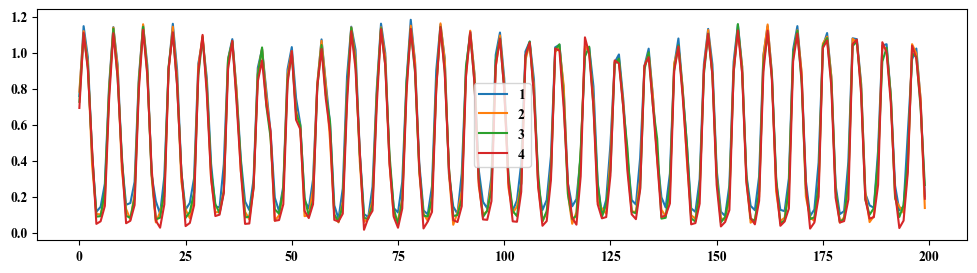

In [170]:
plt.figure(figsize=(12,3))
plt.plot(SPIKE_RATE_DATA[lat_strength_arr[0]][0], label = '1')
plt.plot(SPIKE_RATE_DATA[lat_strength_arr[0]][1], label = '2')
plt.plot(SPIKE_RATE_DATA[lat_strength_arr[0]][2], label = '3')
plt.plot(SPIKE_RATE_DATA[lat_strength_arr[0]][3], label = '4')
plt.legend()
plt.show()

In [171]:
# saving pickle file in the folder path with file name spike_rate.pkl

with open(os.path.join(folder_path, 'spike_rate.pkl'), 'wb') as file:
    pickle.dump(SPIKE_RATE_DATA, file)